In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
import pandas as pd
import numpy as np

file_path = "../data/raw/sales_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (76000, 16)


In [7]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [8]:
print(df.columns.tolist())

['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']


In [9]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
Date
Store ID
Product ID
Category
Region
Inventory Level
Units Sold
Units Ordered
Price
Discount
Weather Condition
Promotion
Competitor Pricing
Seasonality
Epidemic
Demand


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [11]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [13]:
missing = df.isnull().sum()
print(missing)

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64


In [14]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)
print(missing_percentage)

Date                  0.0
Store ID              0.0
Product ID            0.0
Category              0.0
Region                0.0
Inventory Level       0.0
Units Sold            0.0
Units Ordered         0.0
Price                 0.0
Discount              0.0
Weather Condition     0.0
Promotion             0.0
Competitor Pricing    0.0
Seasonality           0.0
Epidemic              0.0
Demand                0.0
dtype: float64


In [15]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [16]:
print(df.columns.tolist())

['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']


In [17]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [18]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Unique dates:", df["Date"].nunique())

Start date: 2022-01-01 00:00:00
End date: 2024-01-30 00:00:00
Unique dates: 760


In [19]:
print("Number of products:", df["Product ID"].nunique())
print("Number of stores:", df["Store ID"].nunique())
print("Number of categories:", df["Category"].nunique())
print("Number of regions:", df["Region"].nunique())

Number of products: 20
Number of stores: 5
Number of categories: 5
Number of regions: 4


In [20]:
print("Units Sold:")
print(df["Units Sold"].describe())

Units Sold:
count    76000.000000
mean        88.827316
std         43.994525
min          0.000000
25%         58.000000
50%         84.000000
75%        114.000000
max        426.000000
Name: Units Sold, dtype: float64


In [21]:
print("Demand:")
print(df["Demand"].describe())

Demand:
count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64


In [22]:
print("Inventory Level:")
print(df["Inventory Level"].describe())

Inventory Level:
count    76000.000000
mean       301.062842
std        226.510161
min          0.000000
25%        136.000000
50%        227.000000
75%        408.000000
max       2267.000000
Name: Inventory Level, dtype: float64


In [23]:
print("Units Ordered:")
print(df["Units Ordered"].describe())

Units Ordered:
count    76000.000000
mean        89.090645
std        162.404627
min          0.000000
25%          0.000000
50%          0.000000
75%        121.000000
max       1616.000000
Name: Units Ordered, dtype: float64


In [24]:
daily_demand = (
    df.groupby("Date")["Demand"]
    .sum()
    .reset_index()
)
daily_demand.head()

,Date,Demand
0,2022-01-01,10060
1,2022-01-02,10814
2,2022-01-03,11317
3,2022-01-04,11469
4,2022-01-05,11724


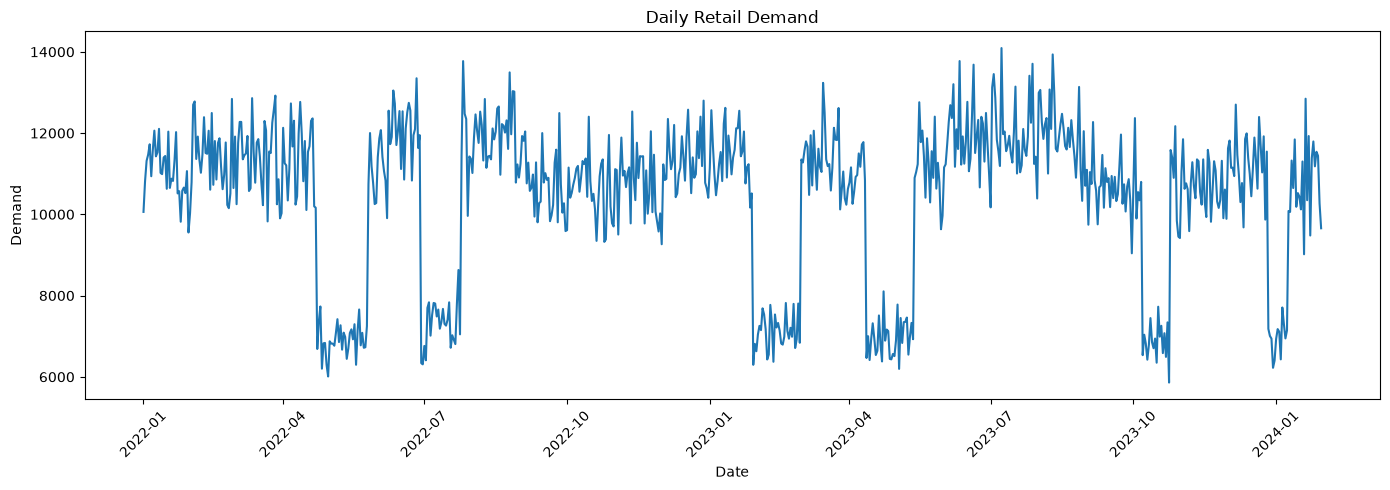

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"]
)
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Daily Retail Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
monthly_demand = (
    df.set_index("Date")
      .resample("ME")["Demand"]
      .sum()
      .reset_index()
)
monthly_demand.head()

,Date,Demand
0,2022-01-31,341544
1,2022-02-28,319883
2,2022-03-31,353173
3,2022-04-30,305076
4,2022-05-31,239112


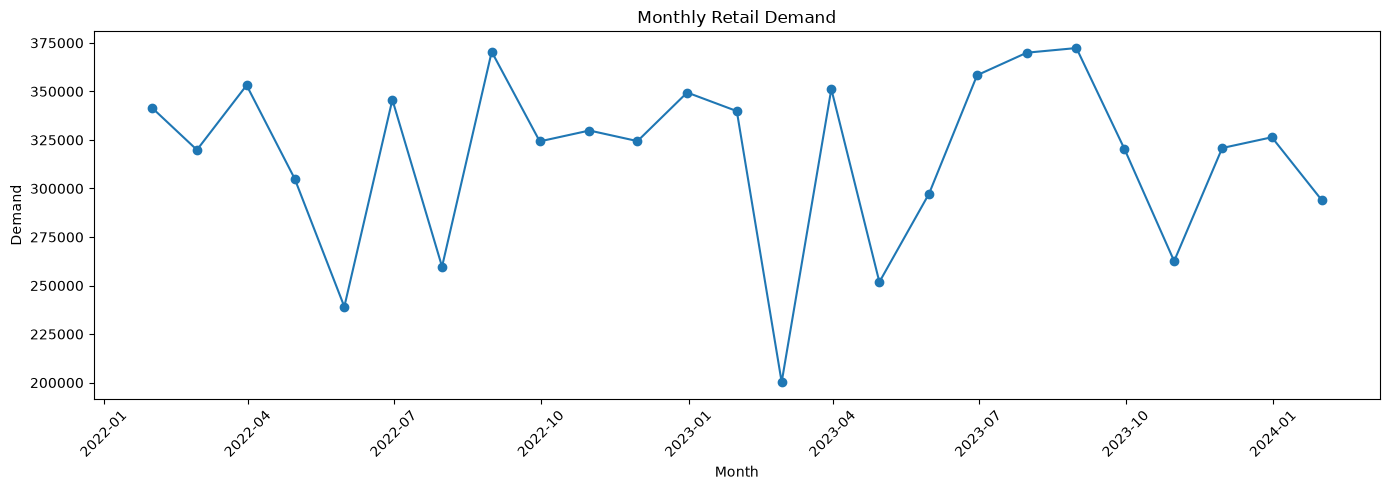

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(
    monthly_demand["Date"],
    monthly_demand["Demand"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Demand")
plt.title("Monthly Retail Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
product_demand = (
    df.groupby("Product ID")["Demand"]
      .sum()
      .sort_values(ascending=False)
)
print(product_demand.head(10))

Product ID
P0009    450324
P0013    440895
P0004    438505
P0007    437089
P0002    425853
P0010    422064
P0001    416447
P0006    409345
P0005    408578
P0008    396538
Name: Demand, dtype: int64


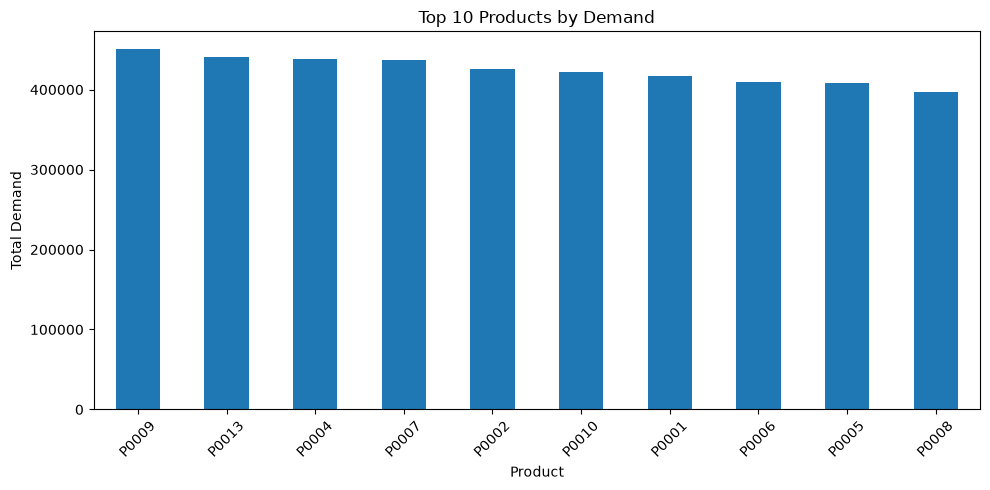

In [29]:
plt.figure(figsize=(10, 5))
product_demand.head(10).plot(kind="bar")
plt.xlabel("Product")
plt.ylabel("Total Demand")
plt.title("Top 10 Products by Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
category_demand = (
    df.groupby("Category")["Demand"]
      .sum()
      .sort_values(ascending=False)
)
print(category_demand)

Category
Groceries      3677684
Clothing       1369456
Furniture      1006590
Toys            985338
Electronics     889036
Name: Demand, dtype: int64


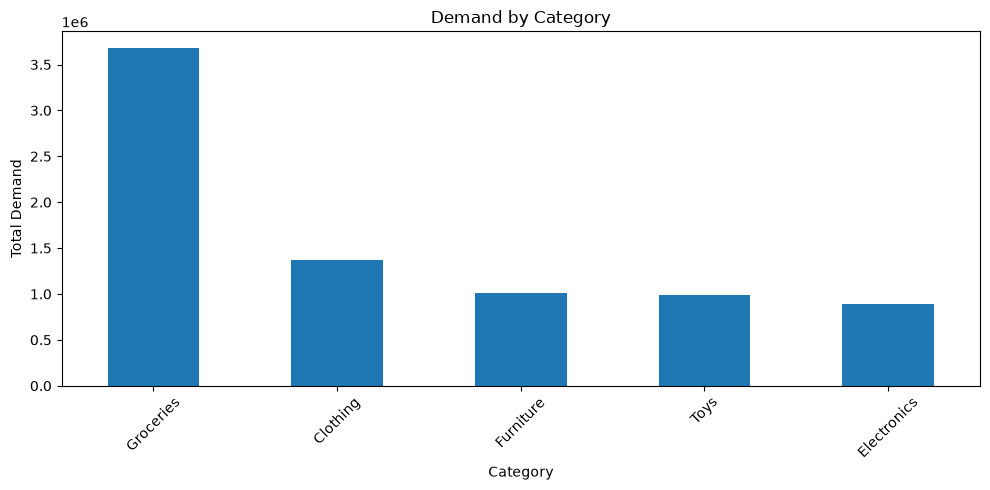

In [31]:
plt.figure(figsize=(10, 5))
category_demand.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Total Demand")
plt.title("Demand by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
promotion_demand = (
    df.groupby("Promotion")["Demand"]
      .mean()
)
print(promotion_demand)

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64


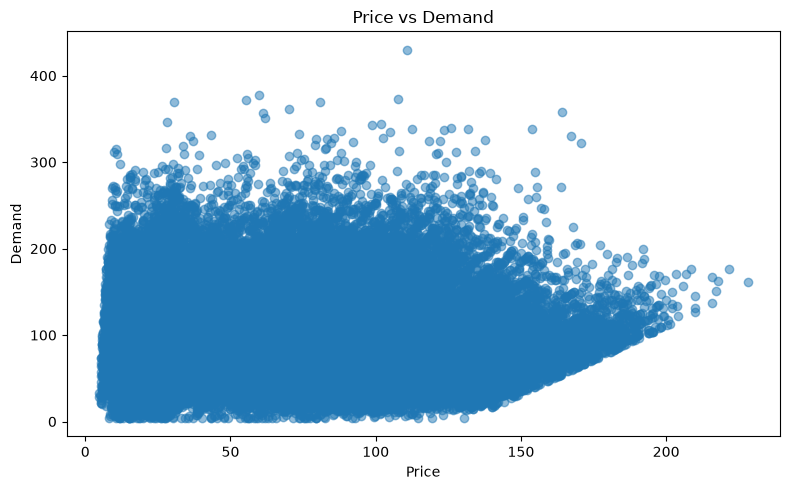

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Price"],
    df["Demand"],
    alpha=0.5
)
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")
plt.tight_layout()
plt.show()

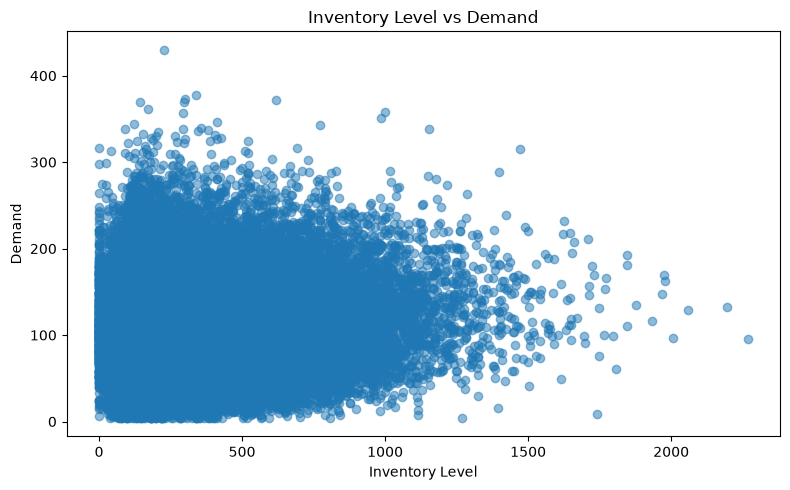

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Inventory Level"],
    df["Demand"],
    alpha=0.5
)
plt.xlabel("Inventory Level")
plt.ylabel("Demand")
plt.title("Inventory Level vs Demand")
plt.tight_layout()
plt.show()

In [35]:
processed_path = "../data/processed/retail_sales_initial.csv"
df.to_csv(
    processed_path,
    index=False
)
print("Processed dataset saved successfully")

Processed dataset saved successfully
